## E1 — Load and Inspect ##
After loading the raw CSV, the dataset has 1610 rows and 10 columns, which matches the expected size from the BigQuery join.

I inspected the dtypes and found one mismatch:

ride_date loaded as string instead of datetime.
This is expected because CSV files store dates as text, and pandas does not automatically convert them. I will fix this in preprocessing.ipynb using pd.to_datetime().

All other columns loaded with the correct types:

Numeric weather columns (temp_f, max_temp_f, min_temp_f, wind_speed_knots, precip_in) loaded as float64

num_rides loaded as int64

avg_duration_min loaded as float64

day_of_week loaded as str

month loaded as int64

The preview of the first few rows confirms that the columns match the schema from Part 0 and the values appear reasonable.

In [3]:
import pandas as pd
df = pd.read_csv('../data/citibike_weather_daily.csv')

In [4]:
df.shape

(1610, 10)

Shape is accurate: as 10 columns, 16010 rows

In [5]:
df.dtypes

ride_date               str
num_rides             int64
avg_duration_min    float64
temp_f              float64
max_temp_f          float64
min_temp_f          float64
wind_speed_knots    float64
precip_in           float64
day_of_week             str
month                 int64
dtype: object

All numeric weather columns loaded as float64 -> good

num_rides loaded as int64 -> good

avg_duration_min loaded as float64 -> good

day_of_week loaded as str -> correct

month loaded as int64 -> correct

 ride_date loaded as str -> incorrect
ride_date should be a datetime type.

In [6]:
df.head()

,ride_date,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,day_of_week,month
0,2013-07-01,16650,16.3,74.8,78.1,73.4,7.8,0.00,Monday,7
1,2013-07-02,22745,16.0,76.1,82.9,73.0,8.0,0.73,Tuesday,7
2,2013-07-03,21864,16.2,78.5,84.9,73.9,8.8,0.06,Wednesday,7
3,2013-07-04,22326,21.2,82.0,91.0,73.9,8.6,0.96,Thursday,7
4,2013-07-05,21842,18.0,84.4,93.0,75.9,9.0,0.00,Friday,7


In [7]:
df.describe()

,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,month
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,32986.783230,15.425342,57.368509,67.317081,49.295901,9.013913,0.178398,6.544099
std,16910.147968,3.652829,17.876211,18.349408,17.832318,3.241211,2.508762,3.323772
min,876.000000,9.500000,8.300000,18.000000,1.000000,2.300000,0.000000,1.000000
25%,20505.500000,13.100000,43.625000,53.700000,35.700000,6.700000,0.000000,4.000000
50%,32272.500000,14.900000,59.300000,70.000000,51.100000,8.500000,0.000000,7.000000
75%,42915.750000,17.100000,73.500000,82.900000,64.900000,10.800000,0.060000,9.000000
max,78458.000000,81.100000,92.500000,100.900000,82.900000,22.400000,99.990000,12.000000


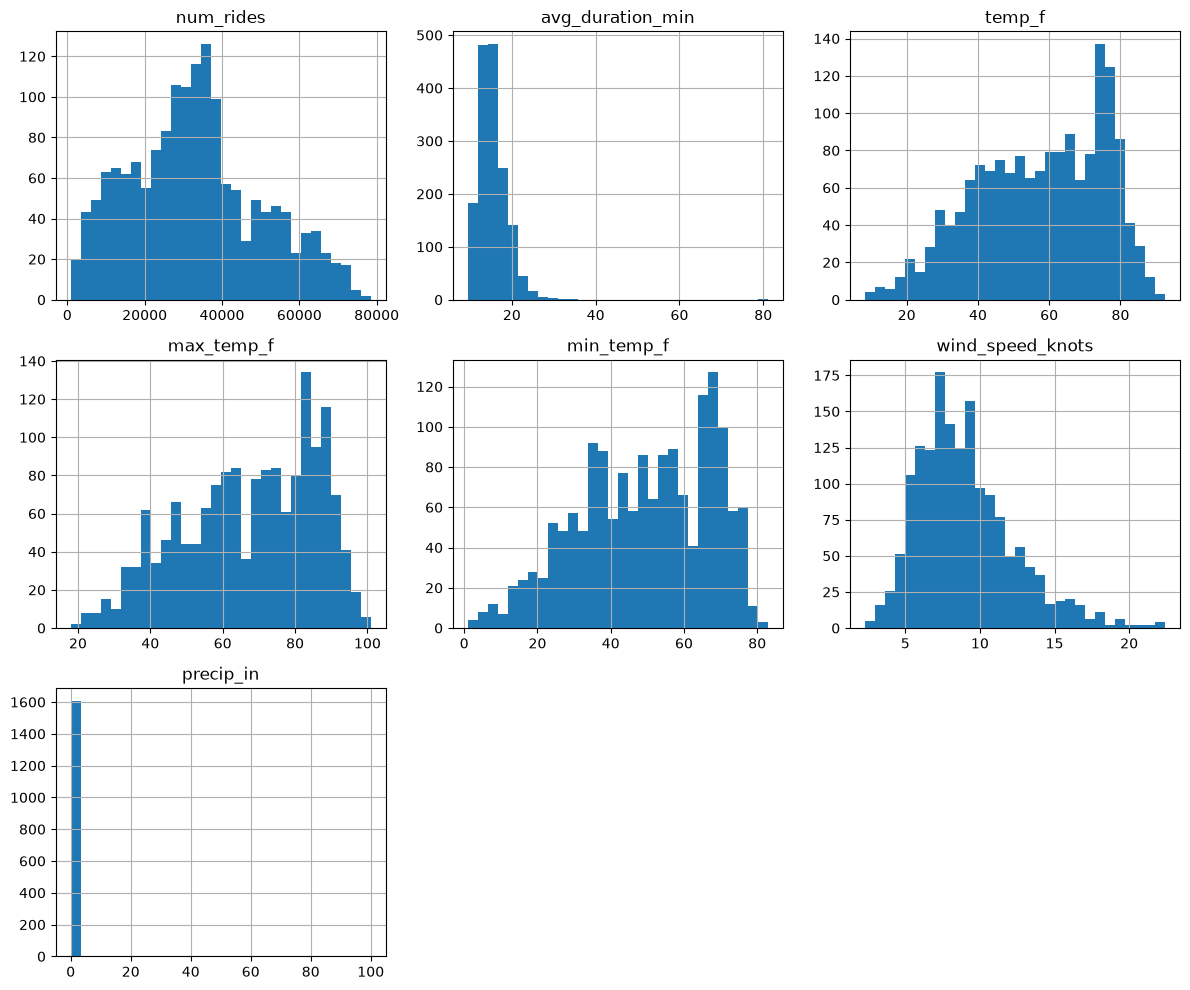

In [8]:
#E3
import matplotlib.pyplot as plt

numeric_cols = [
    'num_rides', 'avg_duration_min', 'temp_f', 'max_temp_f', 'min_temp_f',
    'wind_speed_knots', 'precip_in'
]

df[numeric_cols].hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()

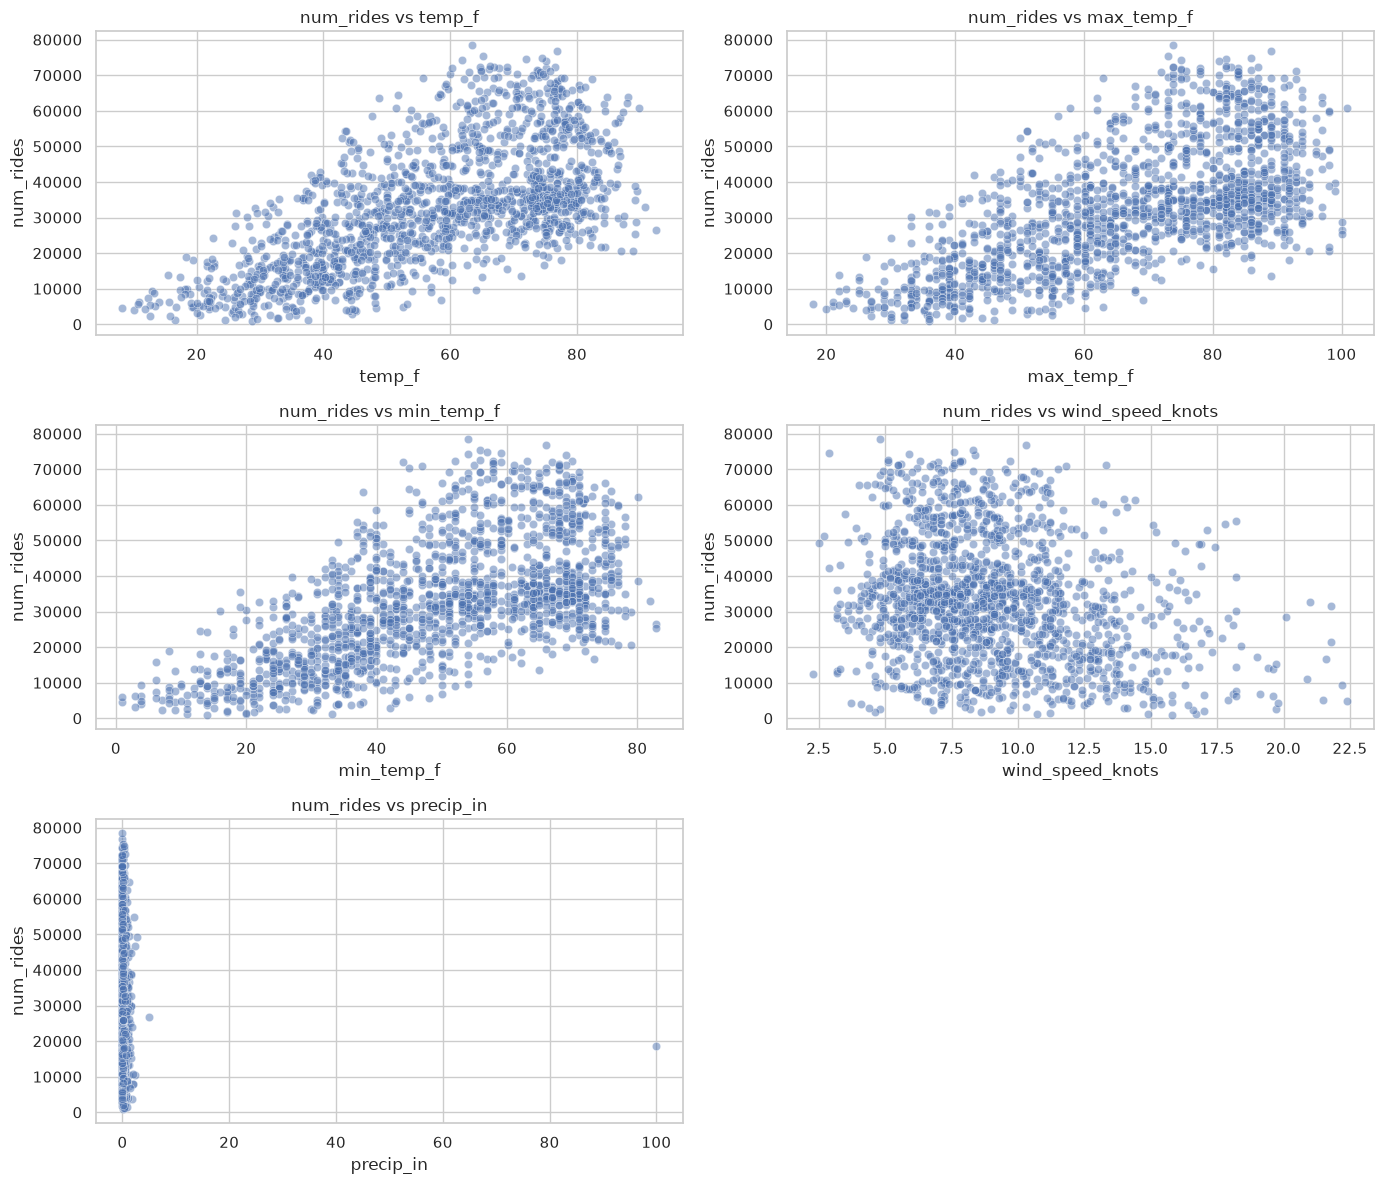

In [12]:
#E3 create scatter plots of the num_rides against the "weather variables": 
# #temp_f , max_temp_f , min_temo_f , wind_temp_f 
# wind_speed_knots , precip_in

import seaborn as sns
sns.set(style="whitegrid")

weather_vars = [
    'temp_f', 'max_temp_f', 'min_temp_f',
    'wind_speed_knots', 'precip_in'
]

plt.figure(figsize=(14, 12))

for i, col in enumerate(weather_vars, 1):
    plt.subplot(3, 2, i)
    sns.scatterplot(data=df, x=col, y='num_rides', alpha=0.5)
    plt.title(f'num_rides vs {col}')

plt.tight_layout()
plt.show()





In [16]:
##E4: Ridership Over Time##
#Plot 1 - number of rides (num_rides) across the full date range
#Plot 2 - Compare July acrosee multiple years 

#Even though dtype fixing officially happens in preprocessing.ipynb,
#we must convert ride_date to datetime here temporarily so matplotlib can plot it.

df['ride_date'] = pd.to_datetime(df['ride_date'])

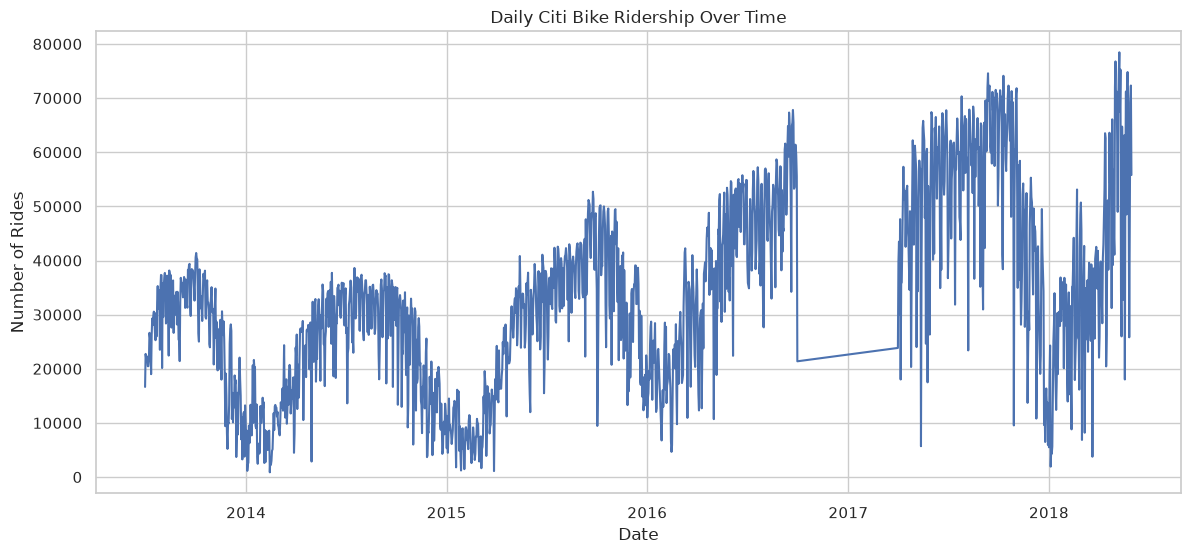

In [18]:
#Plot 1 - number of rides (num_rides) across the full date range (ridership overtime)
plt.figure(figsize=(14,6))
sns.lineplot(data=df, x='ride_date', y='num_rides')
plt.title('Daily Citi Bike Ridership Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Rides')
plt.show()

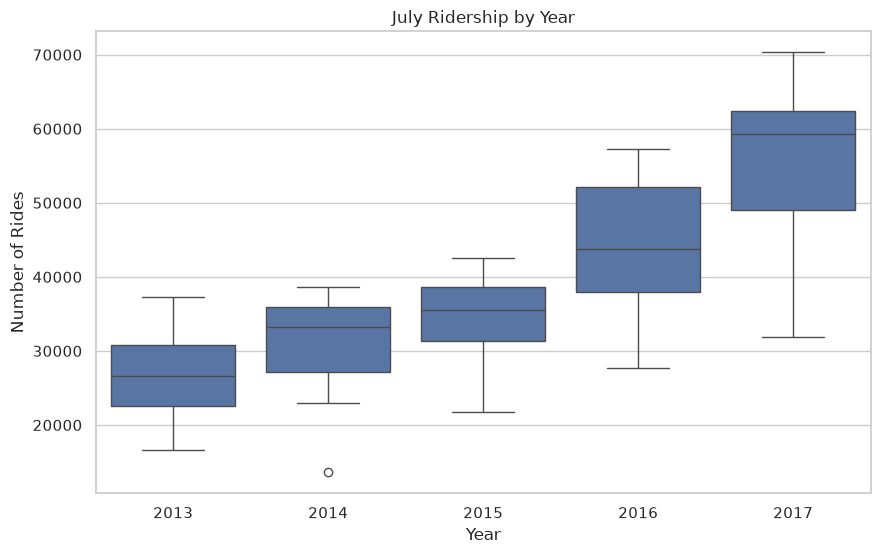

In [ ]:
df['year'] = df['ride_date'].dt.year

july = df[df['month'] == 7]

plt.figure(figsize=(10,6))
sns.boxplot(data=july, x='year', y='num_rides')
plt.title('July Ridership by Year')
plt.xlabel('Year')
plt.ylabel('Number of Rides')
plt.show()

#We compare July across years because weather is stable, ridership is high, and it is the month CitiBike uses as their peak month benchmark

### E5 — Ridership by Day of Week

**Goal:** Compare Citi Bike ridership across days of the week.

**Recommended visualizations:**
- Bar chart of mean daily ridership
- Box plots to show distribution and variability

Questions to answer:
- Which days are the busiest?
- How does weekday vs. weekend ridership compare?
- Does the pattern match your intuition about who rides Citi Bike and why?

#Plot A: Average ridership by day of the week 

#Plot B: Boxplot of ridership by day of week 



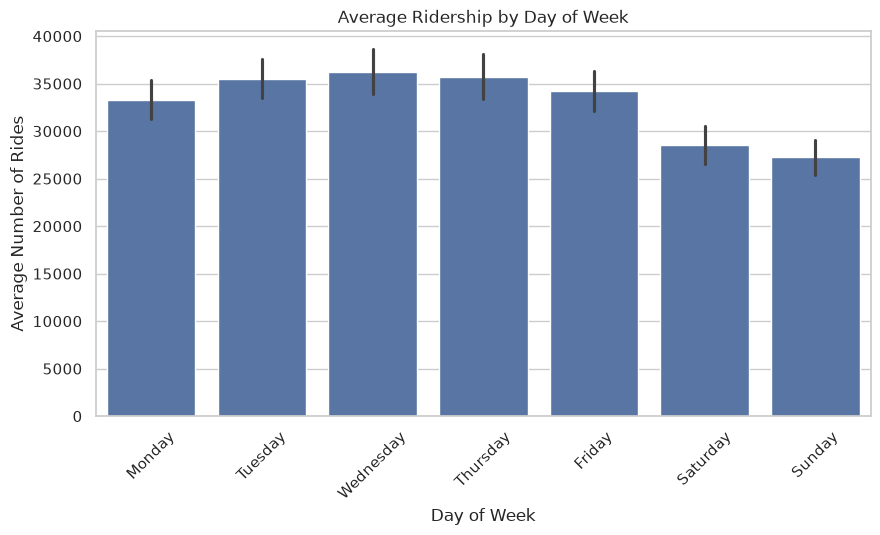

In [ ]:
#We have to maker sure "day_of-week" is a categorical type

df['day_of_week'] = pd.Categorical(
    df['day_of_week'],
    categories=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
    ordered=True
)

#Plot A: Average ridership by day of the week 
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='day_of_week', y='num_rides', estimator='mean')
plt.title('Average Ridership by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Number of Rides')
plt.xticks(rotation=45)
plt.show()


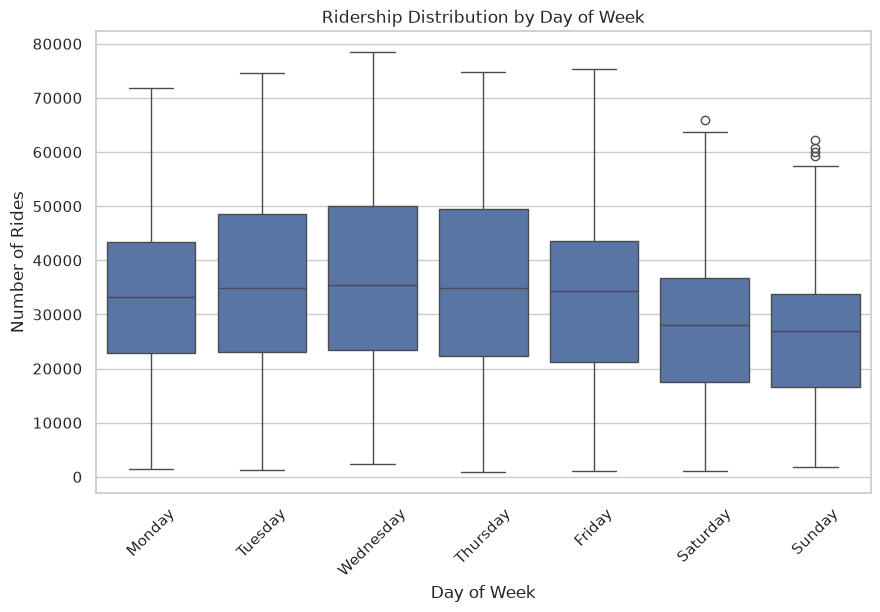

In [36]:
#Plot B: Boxplot of ridership by day of week 
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='day_of_week', y='num_rides')
plt.title('Ridership Distribution by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.show()

**E5 — The Weekly Rhythm**

I plotted average ridership and ridership distributions by day of week. The results show a clear weekly pattern:

• Weekdays (Mon–Fri) have the highest ridership, driven by commuting and regular travel patterns. with the middle of the week showing the highest number of rides.

• Saturday is slightly lower, reflecting more leisure trips and fewer commuters.

• Sunday has the lowest ridership and the widest variability.

The boxplot shows that weekday ridership is consistent and predictable, while weekend ridership varies more due to tourism, weather, and events. This weekly rhythm is a strong signal that the model should include day_of_week (or an encoded version of it) as a feature.


In [31]:
#E6 : Missing Days 
    #1. Generate the full expected date range
    #2. Compare it to the dates in your dataset
    #3. Identify any missing days
    #4. Document findings

full_range = pd.date_range(
    start=df['ride_date'].min(),
    end=df['ride_date'].max(),
    freq='D'
)
#Includes every calendar day in the period

actual_dates = pd.to_datetime(df['ride_date'].unique())

missing_dates = full_range.difference(actual_dates)

missing_dates # will print a list of missing days



DatetimeIndex(['2016-01-23', '2016-01-24', '2016-01-25', '2016-01-26',
               '2016-10-01', '2016-10-02', '2016-10-03', '2016-10-04',
               '2016-10-05', '2016-10-06',
               ...
               '2017-03-22', '2017-03-23', '2017-03-24', '2017-03-25',
               '2017-03-26', '2017-03-27', '2017-03-28', '2017-03-29',
               '2017-03-30', '2017-03-31'],
              dtype='datetime64[us]', length=186, freq=None)

In [33]:
#Counting the missing days
len(missing_dates)

186

**E6 — Missing Days**

I generated the full "expected date range" from the earliest to the latest ride_date and compared it to the "actual dates" in the dataset. The comparison shows that:

186 days are missing from the dataset.

The missing days likely correspond to data outages in either the Citi Bike trip feed or the NOAA GSOD weather feed. These gaps will need to be handled in preprocessing.ipynb, either by dropping the missing dates or labeling/identifying them depending on modeling needs.